# **Day 3: NumPy for Machine Learning**
*Module 1 - Foundations and Tools*

Every ML library (scikit-learn, PyTorch, XGBoost) stores data as **arrays**. NumPy is the foundation: a dataset is a 2D array of shape `(n_samples, n_features)`, an image is `(height, width, channels)`, a batch of images is `(batch, channels, height, width)`.

> NumPy stores numbers in arrays and does maths on the whole array at once, which is much faster than Python loops. Almost every ML library is built on NumPy, so it is the basic language of data in Python.
>
> *Example:* A Sentinel-2 image is just a 3-D array (bands x rows x columns). NDVI for every pixel is one line: `(nir - red) / (nir + red)`, with no loop over millions of pixels.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(3)

## **1. Creating Arrays**

In [2]:
a = np.array([1, 2, 3])                   # from a list
M = np.array([[1, 2, 3], [4, 5, 6]])      # 2D
print("a:", a, "| shape", a.shape, "| ndim", a.ndim, "| dtype", a.dtype)
print("M shape:", M.shape, "-> 2 rows (samples), 3 columns (features)")

print(np.zeros((2, 3)))
print(np.ones(3), np.arange(0, 10, 2), np.linspace(0, 1, 5))
print("Identity:\n", np.eye(3))
print("Random normal:", rng.normal(0, 1, 4).round(3))

a: [1 2 3] | shape (3,) | ndim 1 | dtype int64
M shape: (2, 3) -> 2 rows (samples), 3 columns (features)
[[0. 0. 0.]
 [0. 0. 0.]]
[1. 1. 1.] [0 2 4 6 8] [0.   0.25 0.5  0.75 1.  ]
Identity:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Random normal: [ 2.041 -2.556  0.418 -0.568]


### Data types matter
| dtype | Bytes | Use |
|---|---|---|
| `uint8` | 1 | Images 0-255 |
| `int16`/`uint16` | 2 | Satellite digital numbers (e.g. Sentinel-2 0-10000) |
| `float32` | 4 | **Deep learning default** |
| `float64` | 8 | NumPy / scikit-learn default |

In [3]:
img_uint16 = rng.integers(0, 10000, (1000, 1000), dtype=np.uint16)
print("uint16 :", img_uint16.nbytes / 1e6, "MB")
print("float64:", img_uint16.astype(np.float64).nbytes / 1e6, "MB")
print("float32:", img_uint16.astype(np.float32).nbytes / 1e6, "MB")

x = np.array([250], dtype=np.uint8)
print("Overflow trap: uint8 250 + 10 =", x + np.uint8(10), "(wraps around!) -> convert to float first:", x.astype(float) + 10)

uint16 : 2.0 MB
float64: 8.0 MB
float32: 4.0 MB
Overflow trap: uint8 250 + 10 = [4] (wraps around!) -> convert to float first: [260.]


## **2. Indexing, Slicing and Boolean Masks**

In [4]:
X = np.arange(20).reshape(5, 4)   # 5 samples, 4 features
print(X)
print("Row 0:", X[0])
print("Column 1 (feature 1):", X[:, 1])
print("Last 2 rows, first 2 columns:\n", X[-2:, :2])
print("Rows 0 and 3 (fancy indexing):\n", X[[0, 3]])

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]]
Row 0: [0 1 2 3]
Column 1 (feature 1): [ 1  5  9 13 17]
Last 2 rows, first 2 columns:
 [[12 13]
 [16 17]]
Rows 0 and 3 (fancy indexing):
 [[ 0  1  2  3]
 [12 13 14 15]]


In [5]:
y = np.array([0, 1, 0, 1, 1])
mask = y == 1
print("Mask:", mask)
print("Samples of class 1:\n", X[mask])
print("Values > 10:", X[X > 10])
X2 = X.copy(); X2[X2 > 15] = -1          # replace with a mask
print(X2)

Mask: [False  True False  True  True]
Samples of class 1:
 [[ 4  5  6  7]
 [12 13 14 15]
 [16 17 18 19]]
Values > 10: [11 12 13 14 15 16 17 18 19]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [-1 -1 -1 -1]]


**Views vs copies:** slicing returns a **view** (shares memory). Changing it changes the original. Use `.copy()` when we need independent data.

In [6]:
v = X[0]; v[0] = 999
print("Original changed:", X[0])
X[0, 0] = 0

Original changed: [999   1   2   3]


## **3. Vectorisation: Why Loops Are Slow**
NumPy runs operations in compiled C code over the whole array. Python loops run one element at a time.

In [7]:
import time
x = rng.random(2_000_000)

t = time.perf_counter(); s = 0.0
for v in x:
    s += v * v
t_loop = time.perf_counter() - t

t = time.perf_counter(); s2 = np.sum(x * x)
t_vec = time.perf_counter() - t
print(f"Python loop: {t_loop:.3f}s | NumPy: {t_vec:.4f}s | speed-up: {t_loop / t_vec:.0f}x")

Python loop: 0.271s | NumPy: 0.0044s | speed-up: 61x


## **4. Broadcasting**
When shapes differ, NumPy "stretches" the smaller array. Rules: compare shapes from the right; dimensions are compatible if equal or one of them is 1.

The most common ML use is **standardising features**: subtract each column's mean and divide by its standard deviation.

In [8]:
data = rng.normal([10, 200, 0.5], [2, 50, 0.1], size=(100, 3))   # 3 features on different scales
mu = data.mean(axis=0)        # shape (3,)
sd = data.std(axis=0)         # shape (3,)
Z = (data - mu) / sd          # (100,3) - (3,) -> broadcast over rows
print("Means before:", mu.round(2), "| after:", Z.mean(axis=0).round(6))
print("Stds  after :", Z.std(axis=0).round(6))

# Outer operations with broadcasting: pairwise distances between 5 points
P = rng.random((5, 2))
D = np.sqrt(((P[:, None, :] - P[None, :, :]) ** 2).sum(-1))   # (5,1,2)-(1,5,2) -> (5,5,2)
print("Pairwise distance matrix:\n", D.round(2))

Means before: [ 10.27 200.45   0.51] | after: [-0. -0. -0.]
Stds  after : [1. 1. 1.]
Pairwise distance matrix:
 [[0.   0.96 0.74 0.36 0.82]
 [0.96 0.   0.64 0.9  0.34]
 [0.74 0.64 0.   0.93 0.3 ]
 [0.36 0.9  0.93 0.   0.89]
 [0.82 0.34 0.3  0.89 0.  ]]


## **5. Aggregations Along Axes**
`axis=0` collapses rows (one result **per column/feature**); `axis=1` collapses columns (one result **per row/sample**).

In [9]:
print("Column means (per feature):", X.mean(axis=0))
print("Row sums (per sample)     :", X.sum(axis=1))
print("Index of max per row      :", X.argmax(axis=1))
print("Percentiles of column 0   :", np.percentile(X[:, 0], [25, 50, 75]))

Column means (per feature): [ 8.  9. 10. 11.]
Row sums (per sample)     : [ 6 22 38 54 70]
Index of max per row      : [3 3 3 3 3]
Percentiles of column 0   : [ 4.  8. 12.]


## **6. Images as Arrays: Reshaping Between Image and Table**
A multispectral image has shape `(bands, rows, cols)`. ML models need a table `(pixels, bands)`. After predicting, we reshape back to a map. This round trip is used in every remote sensing project.

Image shape: (4, 60, 80) -> table shape: (4800, 4)


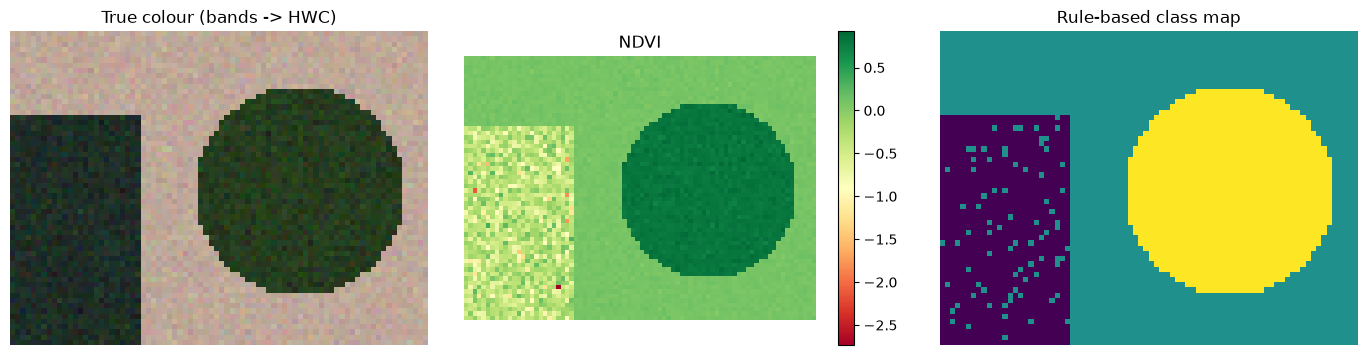

Pixel counts per class: [1022 2533 1245]


In [10]:
bands, rows, cols = 4, 60, 80
yy, xx = np.mgrid[0:rows, 0:cols]
water = (xx < 25) & (yy > 15)                                     # a lake
veg = (~water) & (((xx - 55) ** 2 + (yy - 30) ** 2) < 400)         # a forest patch
img = np.empty((bands, rows, cols), dtype=np.float32)
img[0] = np.where(water, 0.05, np.where(veg, 0.04, 0.20))         # blue
img[1] = np.where(water, 0.06, np.where(veg, 0.08, 0.22))         # green
img[2] = np.where(water, 0.04, np.where(veg, 0.05, 0.25))         # red
img[3] = np.where(water, 0.02, np.where(veg, 0.45, 0.30))         # NIR
img += rng.normal(0, 0.01, img.shape).astype(np.float32)

table = img.reshape(bands, -1).T          # (rows*cols, bands)
print("Image shape:", img.shape, "-> table shape:", table.shape)

ndvi = (table[:, 3] - table[:, 2]) / (table[:, 3] + table[:, 2])   # vectorised index
classes = np.select([ndvi < 0, ndvi > 0.5], [0, 2], default=1)    # 0 water, 1 bare, 2 vegetation
class_map = classes.reshape(rows, cols)                           # back to an image

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
rgb = np.clip(img[[2, 1, 0]].transpose(1, 2, 0) * 3, 0, 1)        # (rows, cols, 3) for imshow
axes[0].imshow(rgb); axes[0].set_title("True colour (bands -> HWC)")
im = axes[1].imshow(ndvi.reshape(rows, cols), cmap="RdYlGn"); axes[1].set_title("NDVI")
fig.colorbar(im, ax=axes[1])
axes[2].imshow(class_map, cmap="viridis"); axes[2].set_title("Rule-based class map")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()
print("Pixel counts per class:", np.bincount(classes))

## **7. Linear Algebra and Random Sampling**

In [11]:
A = rng.normal(size=(3, 3)); b = rng.normal(size=3)
print("Matrix product A @ b:", (A @ b).round(3))
print("Solve Ax = b        :", np.linalg.solve(A, b).round(3))
print("Inverse check       :", np.allclose(A @ np.linalg.inv(A), np.eye(3)))
print("Eigenvalues         :", np.linalg.eigvals(A).round(3))

idx = rng.permutation(10)
print("Shuffled indices (used to split data):", idx)
print("Bootstrap sample (with replacement)  :", rng.choice(10, size=10, replace=True))

Matrix product A @ b: [-0.302  2.548  2.463]
Solve Ax = b        : [1.445 1.422 0.347]
Inverse check       : True
Eigenvalues         : [-1.298+1.276j -1.298-1.276j  1.262+0.j   ]
Shuffled indices (used to split data): [6 2 0 1 5 9 7 3 8 4]
Bootstrap sample (with replacement)  : [3 5 3 8 2 0 6 2 1 5]


# **Part 2: Going Deeper**
## **Memory Layout, Strides and einsum**

A NumPy array is a block of memory plus **strides** (how many bytes to jump for each axis). Transposing only changes strides, which is why it is instant. `np.einsum` writes complex tensor operations in one readable line; it is used inside deep-learning libraries (e.g. attention, Day 67).

In [12]:
B = np.zeros((1000, 500), dtype=np.float64)
print("Shape", B.shape, "strides", B.strides, "| transposed strides", B.T.strides)
print("C-contiguous:", B.flags["C_CONTIGUOUS"], "| transposed:", B.T.flags["C_CONTIGUOUS"])

Q = rng.normal(size=(2, 5, 8)); K = rng.normal(size=(2, 5, 8))
scores = np.einsum("bqd,bkd->bqk", Q, K)       # batched Q @ K^T
print("einsum matches matmul:", np.allclose(scores, Q @ K.transpose(0, 2, 1)), scores.shape)

Shape (1000, 500) strides (4000, 8) | transposed strides (8, 4000)
C-contiguous: True | transposed: False
einsum matches matmul: True (2, 5, 5)


### Sliding windows without loops
`sliding_window_view` creates overlapping patches as a **view** (no copy). It is useful for moving averages, texture features and image patches.

Windows shape: (56, 76, 5, 5)


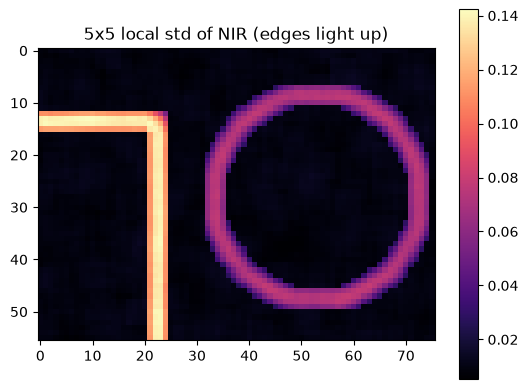

In [13]:
from numpy.lib.stride_tricks import sliding_window_view
win = sliding_window_view(img[3], (5, 5))                 # all 5x5 windows of the NIR band
local_std = win.std(axis=(-1, -2))                         # texture: local standard deviation
print("Windows shape:", win.shape)
plt.imshow(local_std, cmap="magma"); plt.title("5x5 local std of NIR (edges light up)"); plt.colorbar(); plt.show()

## **Practice Problems**
1. Create a 6x4 random array and standardise each column (mean 0, std 1) using broadcasting.
2. From `table`, select all pixels with NIR > 0.35 and compute their mean in each band.
3. Compute the NDWI = (green - NIR) / (green + NIR) map from `img` without any loops.
4. *(Advanced)* Compute the Euclidean distance from every pixel in `table` to 3 class-mean vectors with one broadcasting expression, and assign each pixel to the nearest mean (a minimum-distance classifier).

In [14]:
# Solution 1
A6 = rng.random((6, 4)); Zs = (A6 - A6.mean(0)) / A6.std(0)
print(Zs.mean(0).round(6), Zs.std(0).round(6))
# Solution 2
print("Mean bands of high-NIR pixels:", table[table[:, 3] > 0.35].mean(axis=0).round(3))
# Solution 3
ndwi = (img[1] - img[3]) / (img[1] + img[3])
print("NDWI range:", ndwi.min().round(2), ndwi.max().round(2))
# Solution 4
means = np.stack([table[classes == k].mean(0) for k in range(3)])         # (3, bands)
dist = np.linalg.norm(table[:, None, :] - means[None, :, :], axis=-1)     # (pixels, 3)
md_class = dist.argmin(1)
print("Agreement with NDVI rules:", (md_class == classes).mean().round(3))

[ 0.  0.  0. -0.] [1. 1. 1. 1.]
Mean bands of high-NIR pixels: [0.04 0.08 0.05 0.45]
NDWI range: -0.83 1.94
Agreement with NDVI rules: 0.984


## **Key References**
- Harris, C. R. et al. (2020). Array programming with NumPy. *Nature*, 585, 357-362.
- van der Walt, S., Colbert, S. C., & Varoquaux, G. (2011). The NumPy array: a structure for efficient numerical computation. *Computing in Science & Engineering*, 13(2), 22-30.